<a href="https://colab.research.google.com/github/daniafzc/tugas2pcd/blob/main/PCD_Assignment02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

# 1. Load Dataset
Dipilih 3 gambar yang mewakilkan permasalahan pada citra, yaitu blur, low contrast, dan under exposure.

In [2]:
os.makedirs('images', exist_ok=True)

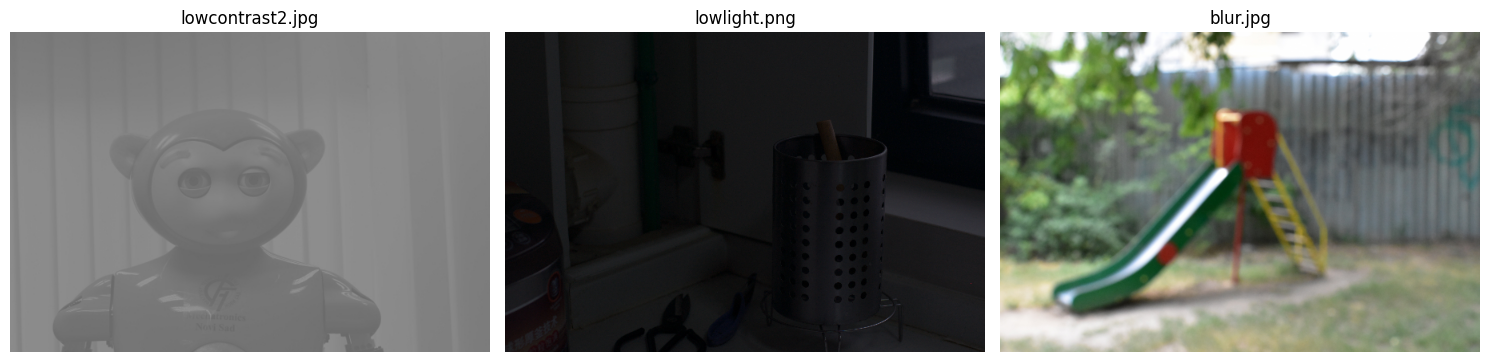

In [6]:
folder = 'images'
filenames = ['lowcontrast2.jpg', 'lowlight.png', 'blur.jpg']

images = {}
for fname in filenames:
    path = os.path.join(folder, fname)
    img = cv2.imread(path)
    assert img is not None, f"Gagal load {fname}"
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    images[fname] = img_rgb

fig, axes = plt.subplots(1, len(images), figsize=(15, 5))
for ax, (fname, img) in zip(axes, images.items()):
    ax.imshow(img)
    ax.set_title(fname)
    ax.axis('off')
plt.tight_layout()
plt.show()

# 2. Identifikasi Histogram

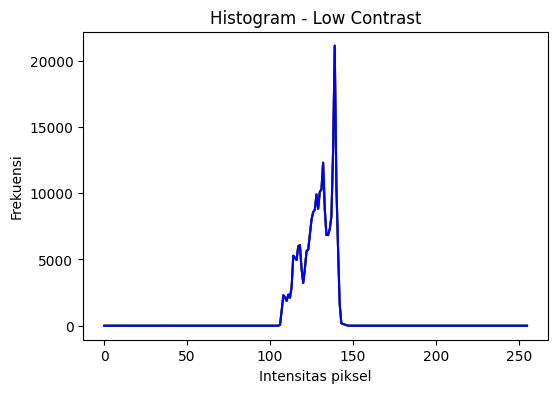

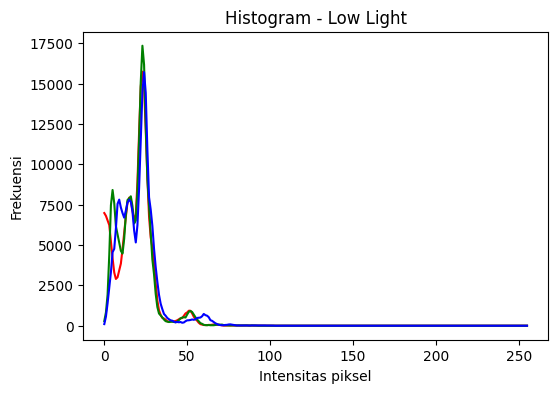

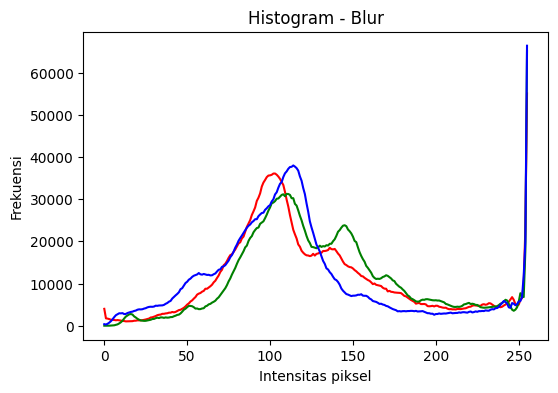

In [7]:
def plot_histogram(img_rgb, title):
    colors = ('r', 'g', 'b')
    plt.figure(figsize=(6, 4))
    for i, col in enumerate(colors):
        hist = cv2.calcHist([img_rgb], [i], None, [256], [0, 256])
        plt.plot(hist, color=col)
    plt.title(title)
    plt.xlabel('Intensitas piksel')
    plt.ylabel('Frekuensi')
    plt.show()

plot_histogram(images['lowcontrast2.jpg'], 'Histogram - Low Contrast')
plot_histogram(images['lowlight.png'], 'Histogram - Low Light')
plot_histogram(images['blur.jpg'], 'Histogram - Blur')

# 3. Under Exposure (lowlight.png)
### Log Transform

In [9]:
def log_transform_channel(channel):
    channel_float = channel.astype(np.float64)
    c = 255 / np.log(1 + np.max(channel_float))
    log_channel = c * np.log(1 + channel_float)
    return np.uint8(log_channel)

hsv_lowlight = cv2.cvtColor(images['lowlight.png'], cv2.COLOR_RGB2HSV)
h, s, v = cv2.split(hsv_lowlight)
v_log = log_transform_channel(v)
hsv_result = cv2.merge([h, s, v_log])
result_lowlight = cv2.cvtColor(hsv_result, cv2.COLOR_HSV2RGB)

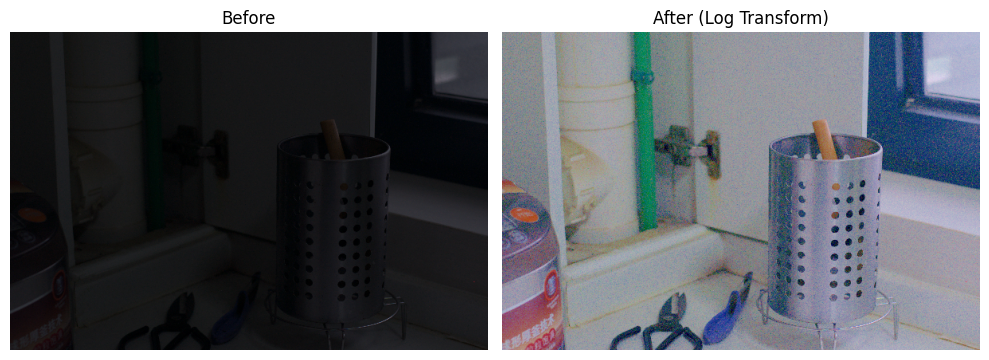

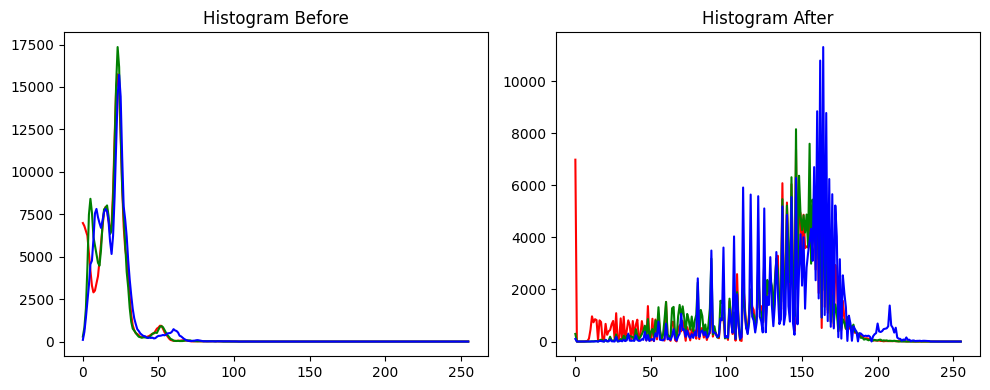

In [10]:
# before vs after
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(images['lowlight.png']); axes[0].set_title('Before'); axes[0].axis('off')
axes[1].imshow(result_lowlight); axes[1].set_title('After (Log Transform)'); axes[1].axis('off')
plt.tight_layout()
plt.show()

# histogram before vs after
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = ('r', 'g', 'b')
for i, col in enumerate(colors):
    axes[0].plot(cv2.calcHist([images['lowlight.png']], [i], None, [256], [0, 256]), color=col)
    axes[1].plot(cv2.calcHist([result_lowlight], [i], None, [256], [0, 256]), color=col)
axes[0].set_title('Histogram Before')
axes[1].set_title('Histogram After')
plt.tight_layout()
plt.show()

# 4. Low Contrast (lowcontrast2.jpg)
### Contrast Stretching dan Histogram Qualization

In [13]:
def contrast_stretching_channel(channel):
    min_val = np.min(channel)
    max_val = np.max(channel)
    stretched = (channel.astype(np.float64) - min_val) * (255.0 / (max_val - min_val))
    return np.uint8(stretched)

hsv_lc = cv2.cvtColor(images['lowcontrast2.jpg'], cv2.COLOR_RGB2HSV)
h, s, v = cv2.split(hsv_lc)

v_stretched = contrast_stretching_channel(v)
result_lowcontrast_stretch = cv2.cvtColor(cv2.merge([h, s, v_stretched]), cv2.COLOR_HSV2RGB)

v_eq = cv2.equalizeHist(v)
result_lowcontrast_eq = cv2.cvtColor(cv2.merge([h, s, v_eq]), cv2.COLOR_HSV2RGB)

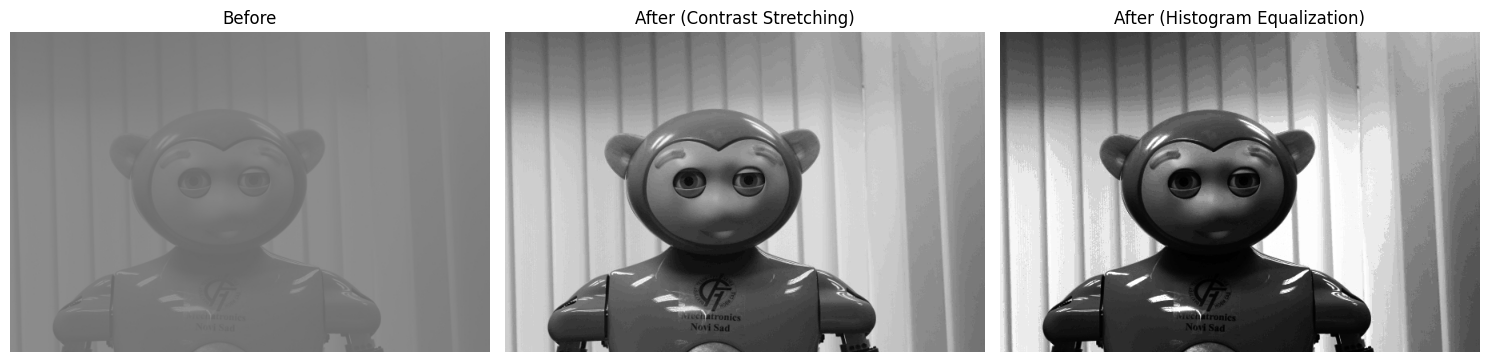

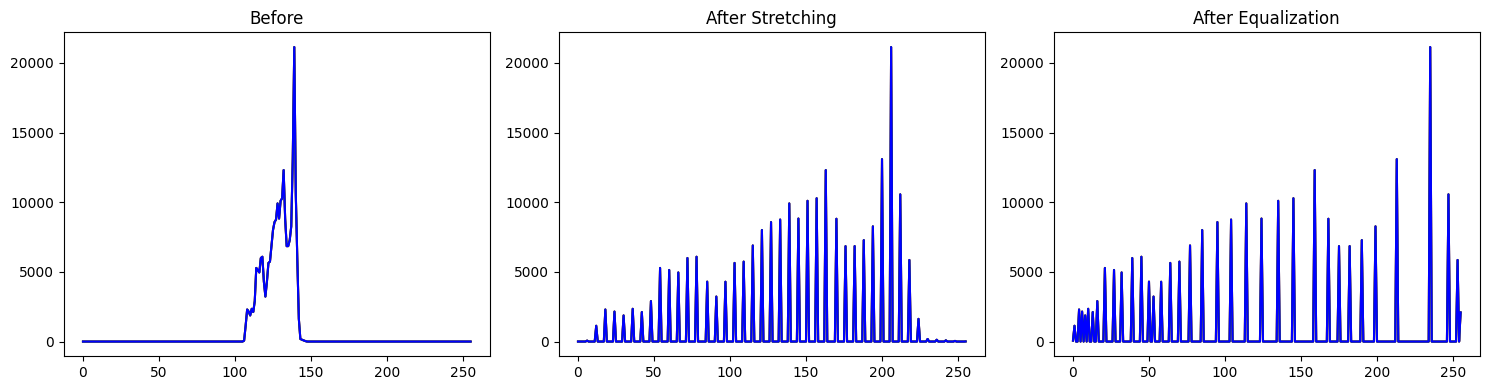

In [15]:
# before vs kedua hasil
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(images['lowcontrast2.jpg']); axes[0].set_title('Before'); axes[0].axis('off')
axes[1].imshow(result_lowcontrast_stretch); axes[1].set_title('After (Contrast Stretching)'); axes[1].axis('off')
axes[2].imshow(result_lowcontrast_eq); axes[2].set_title('After (Histogram Equalization)'); axes[2].axis('off')
plt.tight_layout()
plt.show()

# histogram before vs kedua hasil
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(colors):
    axes[0].plot(cv2.calcHist([images['lowcontrast2.jpg']], [i], None, [256], [0, 256]), color=col)
    axes[1].plot(cv2.calcHist([result_lowcontrast_stretch], [i], None, [256], [0, 256]), color=col)
    axes[2].plot(cv2.calcHist([result_lowcontrast_eq], [i], None, [256], [0, 256]), color=col)
axes[0].set_title('Before'); axes[1].set_title('After Stretching'); axes[2].set_title('After Equalization')
plt.tight_layout()
plt.show()

# 5. Blur (blur.jpg)
### Sharpening

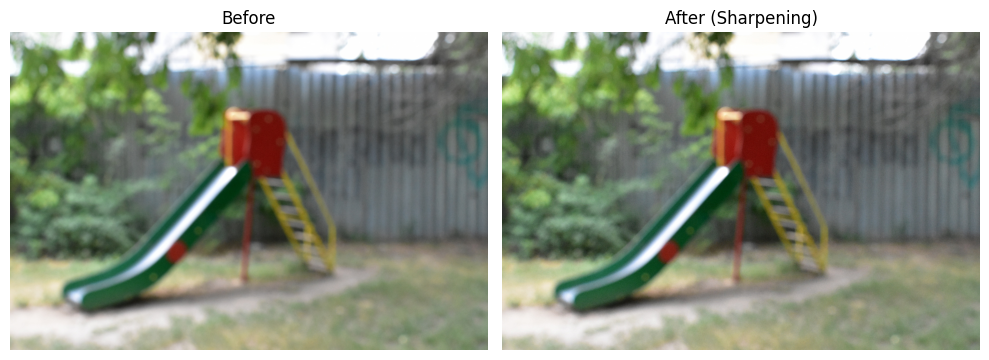

In [16]:
blurred = cv2.GaussianBlur(images['blur.jpg'], (0, 0), sigmaX=3)
result_blur = cv2.addWeighted(images['blur.jpg'], 1.5, blurred, -0.5, 0)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(images['blur.jpg']); axes[0].set_title('Before'); axes[0].axis('off')
axes[1].imshow(result_blur); axes[1].set_title('After (Sharpening)'); axes[1].axis('off')
plt.tight_layout()
plt.show()